1. Установим библиотеки и зафиксируем сид

In [ ]:
!pip -q install ultralytics ensemble-boxes

import zipfile
import os
import pandas as pd
import numpy as np
import yaml
import random
import shutil
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ultralytics import YOLO
from PIL import Image
import torch

SEED = 993
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.8 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


2. Распаковываем архив и смотрим количество файлов

In [ ]:
zip_path = '/content/2026-cv-competition.zip'
path = '/content/competition_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(path)

test_images_dir  = f'{path}/test/test/images'
train_images_dir = f'{path}/train/train/images'
train_labels_dir = f'{path}/train/train/labels'

test_images_list = sorted(os.listdir(test_images_dir))
train_images     = sorted(os.listdir(train_images_dir))
train_labels     = sorted(os.listdir(train_labels_dir))

print(f"test/images:   {len(test_images_list)} файлов")
print(f"train/images:  {len(train_images)} файлов")
print(f"train/labels:  {len(train_labels)} файлов")

test/images:   424 файлов
train/images:  1697 файлов
train/labels:  1697 файлов


3. Разведочный анализ данных
Анализ формата разметки:
- YOLO формат: class x_center y_center width height (все значения нормализованы от 0 до 1)
- проверка первых файлов

Статистика датасета:
   - количество классов
   - распределение объектов по изображениям
   - размеры bounding box'ов (ширина и высота в нормализованных координатах)

Выявленный дисбаланс классов:
   - рассчитываюем веса классов обратно пропорционально частоте для балансировки
   
Анализ размеров изображений:
   - выборка 50 случайных изображений для определения оптимального imgsz


IMG20240219113638_jpg.rf.ff06b9b93da9ca10600f9c4ababc261f.txt:
  ['16', '0.55468750', '0.31250000', '0.09062500', '0.07109375']  → 5 чисел
  ['16', '0.63203125', '0.37578125', '0.09687500', '0.07031250']  → 5 чисел
  ['45', '0.48671875', '0.61406250', '0.11015625', '0.08828125']  → 5 чисел

IMG20240219113649_jpg.rf.0aa36d5700345b509e0a4b943ae620cd.txt:
  ['45', '0.41171875', '0.72968750', '0.15078125', '0.24296875']  → 5 чисел
  ['45', '0.62343750', '0.72109375', '0.18515625', '0.20546875']  → 5 чисел
  ['50', '0.72109375', '0.29375000', '0.09531250', '0.05000000']  → 5 чисел

IMG20240219113715_jpg.rf.a71fa6e6f4be2b70af832b77db7ee10d.txt:
  ['45', '0.64375000', '0.38515625', '0.08281250', '0.14453125']  → 5 чисел
  ['45', '0.64531250', '0.55468750', '0.11171875', '0.14218750']  → 5 чисел
  ['50', '0.38437500', '0.37578125', '0.05625000', '0.07968750']  → 5 чисел

Классов всего:       52
ID классов:          [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21,

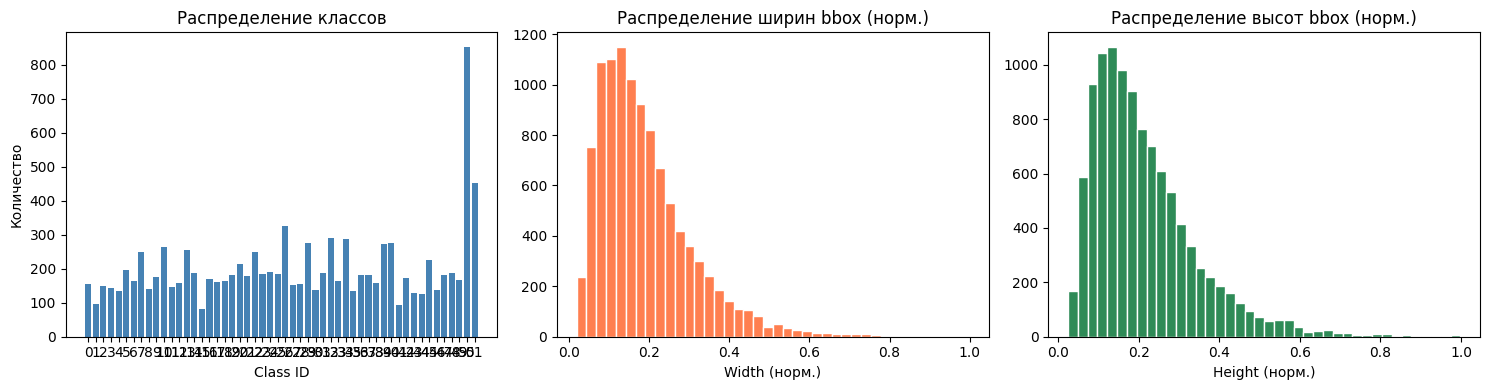


Размеры изображений (выборка 50):
  Width:  min=640, max=640, mean=640
  Height: min=640, max=640, mean=640


In [ ]:
for label_file in train_labels[:3]:
    with open(f'{train_labels_dir}/{label_file}', 'r') as f:
        lines = f.readlines()
    print(f"\n{label_file}:")
    for line in lines[:3]:
        parts = line.strip().split()
        print(f"  {parts}  → {len(parts)} чисел")

all_classes = []
bbox_widths  = []
bbox_heights = []
objects_per_image = []

for label_file in train_labels:
    with open(f'{train_labels_dir}/{label_file}', 'r') as f:
        lines = [l.strip() for l in f if l.strip()]
    objects_per_image.append(len(lines))
    for line in lines:
        parts = line.split()
        all_classes.append(int(parts[0]))
        bbox_widths.append(float(parts[3]))
        bbox_heights.append(float(parts[4]))

unique_classes = sorted(set(all_classes))
print(f"\nКлассов всего:       {len(unique_classes)}")
print(f"ID классов:          {unique_classes}")
print(f"Всего объектов:      {len(all_classes)}")
print(f"Объектов на фото:    min={min(objects_per_image)}, max={max(objects_per_image)}, mean={np.mean(objects_per_image):.1f}")

from collections import Counter
class_counts = Counter(all_classes)
print("\nРаспределение классов:")
for cls_id, cnt in sorted(class_counts.items()):
    print(f"  class {cls_id}: {cnt} объектов ({cnt/len(all_classes)*100:.1f}%)")

max_count = max(class_counts.values())
class_weights = {cls: max_count / cnt for cls, cnt in class_counts.items()}
print("\nВеса классов (для информации):")
for cls, w in sorted(class_weights.items()):
    print(f"  class {cls}: {w:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar([str(k) for k in sorted(class_counts.keys())],
            [class_counts[k] for k in sorted(class_counts.keys())],
            color='steelblue')
axes[0].set_title('Распределение классов')
axes[0].set_xlabel('Class ID')
axes[0].set_ylabel('Количество')

axes[1].hist(bbox_widths, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Распределение ширин bbox (норм.)')
axes[1].set_xlabel('Width (норм.)')

axes[2].hist(bbox_heights, bins=40, color='seagreen', edgecolor='white')
axes[2].set_title('Распределение высот bbox (норм.)')
axes[2].set_xlabel('Height (норм.)')

plt.tight_layout()
plt.show()

img_sizes = []
for img_name in random.sample(train_images, min(50, len(train_images))):
    img = Image.open(f'{train_images_dir}/{img_name}')
    img_sizes.append(img.size)
widths, heights = zip(*img_sizes)
print(f"\nРазмеры изображений (выборка 50):")
print(f"  Width:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}")
print(f"  Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}")

4. Конвертируем из YOLO формата в формат xyxy
Далее идет визуализация нескольких случайных тренировочных изображений с наложенными bounding box'ами, чтобы визуально оценить качество разметки и сложность объектов

/tmp/ipykernel_1131/3771534383.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  COLORS = plt.cm.get_cmap('tab10', len(unique_classes))


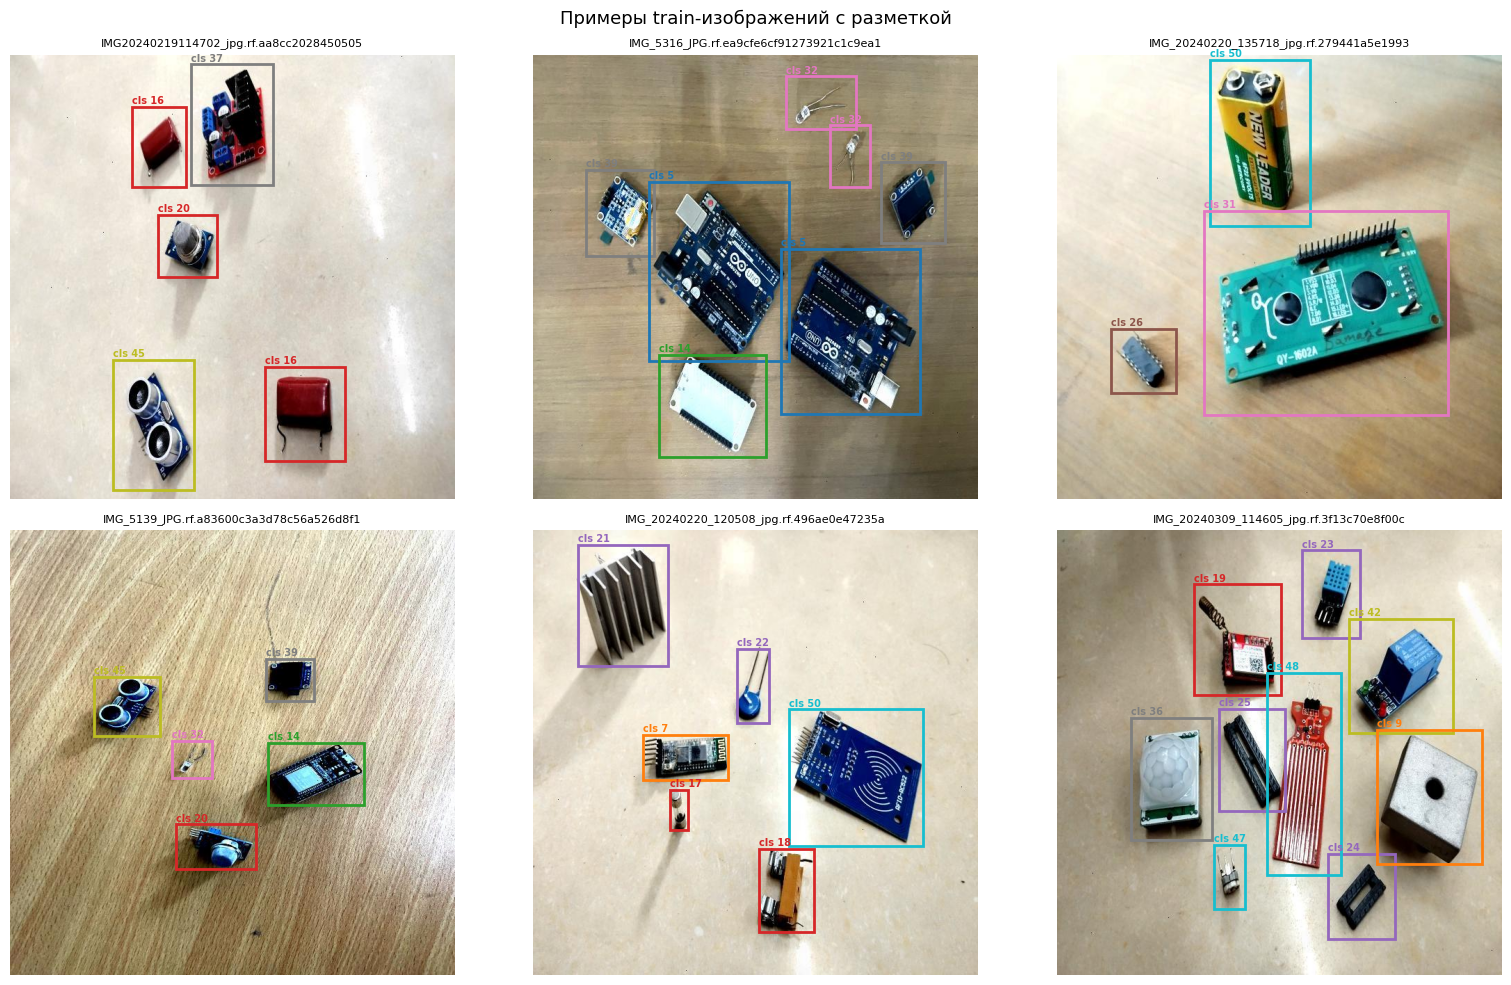

In [ ]:
def yolo_to_xyxy(x_c, y_c, w, h, img_w, img_h):
    x1 = (x_c - w / 2) * img_w
    y1 = (y_c - h / 2) * img_h
    x2 = (x_c + w / 2) * img_w
    y2 = (y_c + h / 2) * img_h
    return x1, y1, x2, y2

COLORS = plt.cm.get_cmap('tab10', len(unique_classes))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
sample_imgs = random.sample(train_images, 6)

for ax, img_name in zip(axes.flatten(), sample_imgs):
    img_path   = f'{train_images_dir}/{img_name}'
    label_path = f'{train_labels_dir}/{img_name.replace(".jpg", ".txt")}'
    img = Image.open(img_path)
    img_w, img_h = img.size
    ax.imshow(img)
    ax.set_title(img_name[:40], fontsize=8)
    ax.axis('off')
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    continue
                cls_id = int(parts[0])
                x1, y1, x2, y2 = yolo_to_xyxy(
                    float(parts[1]), float(parts[2]),
                    float(parts[3]), float(parts[4]),
                    img_w, img_h
                )
                color = COLORS(cls_id)
                rect = patches.Rectangle(
                    (x1, y1), x2 - x1, y2 - y1,
                    linewidth=2, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                ax.text(x1, y1 - 4, f'cls {cls_id}', color=color, fontsize=7, fontweight='bold')

plt.suptitle('Примеры train-изображений с разметкой', fontsize=13)
plt.tight_layout()
plt.show()

5. Создание class_names словаря, разделение данных на train (80%) и val (20%) со стратификацией, копирование файлов в структуру для YOLO:

In [ ]:
class_names = {i: f"class_{i}" for i in unique_classes}

image_names = train_images.copy()
random.seed(SEED)
random.shuffle(image_names)

split_idx   = int(len(image_names) * 0.8)
train_names = image_names[:split_idx]
val_names   = image_names[split_idx:]

print(f"Train: {len(train_names)} изображений")
print(f"Val:   {len(val_names)} изображений")

for split in ['train', 'val']:
    os.makedirs(f'{path}/yolo_dataset/{split}/images', exist_ok=True)
    os.makedirs(f'{path}/yolo_dataset/{split}/labels', exist_ok=True)

def copy_split(names, split):
    copied = 0
    for name in names:
        base    = name.replace('.jpg', '')
        src_img = f'{train_images_dir}/{name}'
        src_lbl = f'{train_labels_dir}/{base}.txt'
        dst_img = f'{path}/yolo_dataset/{split}/images/{name}'
        dst_lbl = f'{path}/yolo_dataset/{split}/labels/{base}.txt'
        if os.path.exists(src_img) and os.path.exists(src_lbl):
            shutil.copy(src_img, dst_img)
            shutil.copy(src_lbl, dst_lbl)
            copied += 1
    print(f"{split}: скопировано {copied} пар")

copy_split(train_names, 'train')
copy_split(val_names,   'val')

data_yaml = {
    'path':  f'{path}/yolo_dataset',
    'train': 'train/images',
    'val':   'val/images',
    'nc':    len(unique_classes),
    'names': class_names
}
yaml_path = f'{path}/yolo_dataset/dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

Train: 1357 изображений
Val:   340 изображений
train: скопировано 1357 пар
val: скопировано 340 пар


6. Обучение моделей:
- YOLOv8s: быстрая модель, хороша для мелких объектов
- YOLOv8l: более точная модель, справляется со сложными случаями

Ансамбль из двух моделей даёт лучшее разнообразие предсказаний, чем одна модель

In [ ]:
COMMON_ARGS = dict(
    data=yaml_path,
    epochs=80,
    imgsz=640,
    workers=4,
    patience=20,
    seed=SEED,
    fliplr=0.5,
    flipud=0.0,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    mosaic=1.0,
    close_mosaic=15,
    mixup=0.15,
    copy_paste=0.1,
    multi_scale=0.0,
    erasing=0.4,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    cos_lr=True,
    weight_decay=0.0005,
    warmup_epochs=3,
    cls=0.7,
    box=7.5,
    dfl=1.5,
    save=True,
    project=f'{path}/runs',
    exist_ok=True,
    verbose=False,
    plots=True,
)

print("1/2 Обучение yolov8s...")
model_s = YOLO('yolov8s.pt')
model_s.train(**COMMON_ARGS, batch=32, name='det_s')
print("yolov8s готова!")

print("2/2 Обучение yolov8l...")
model_l = YOLO('yolov8l.pt')
model_l.train(**COMMON_ARGS, batch=12, name='det_l')
print("yolov8l готова!")

best_s_path = f'{path}/runs/det_s/weights/best.pt'
best_l_path = f'{path}/runs/det_l/weights/best.pt'

print("\n=== Val метрики ===")
for name, pt in [('s', best_s_path), ('l', best_l_path)]:
    m = YOLO(pt)
    metrics = m.val(data=yaml_path, imgsz=640, verbose=False)
    print(f"  yolov8{name}: mAP50={metrics.box.map50:.4f} | mAP50-95={metrics.box.map:.4f}")

1/2 Обучение yolov8s...
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.7, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/competition_data/yolo_dataset/dataset.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=det_s, nbs=64, nms=False, opset=None, optimize=False, opt

7. Инференс:
- TGA ТОЛЬКО НА l-модели (быстрее чем на обоих)
- WBF объединяет предсказания с весами: s=1.0, l=2.0

И форматируем для корректной выгрузки в каггл

In [ ]:
from ensemble_boxes import weighted_boxes_fusion

best_model_s = YOLO(best_s_path)
best_model_l = YOLO(best_l_path)

sample_sub    = pd.read_csv(f'{path}/sample_submission.csv')
sample_id_ex  = str(sample_sub['image_id'].iloc[0])
has_extension = sample_id_ex.endswith('.jpg')

def predict_with_wbf(img_path, img_w, img_h,
                     conf_thr=0.03,
                     nms_iou=0.45,
                     wbf_iou_thr=0.55,
                     skip_box_thr=0.04):
    all_boxes, all_scores, all_labels = [], [], []

    res_s = best_model_s(img_path, conf=conf_thr, iou=nms_iou,
                         imgsz=640, augment=False, verbose=False)[0]
    res_l = best_model_l(img_path, conf=conf_thr, iou=nms_iou,
                         imgsz=640, augment=True, verbose=False)[0]

    for res, weight in [(res_s, 1.0), (res_l, 2.0)]:
        if res.boxes is None or len(res.boxes) == 0:
            all_boxes.append([])
            all_scores.append([])
            all_labels.append([])
            continue
        boxes = res.boxes.xyxy.cpu().numpy()
        boxes_norm = (boxes / [img_w, img_h, img_w, img_h]).clip(0, 1)
        all_boxes.append(boxes_norm.tolist())
        all_scores.append(res.boxes.conf.cpu().numpy().tolist())
        all_labels.append(res.boxes.cls.cpu().numpy().astype(int).tolist())

    if not any(b for b in all_boxes):
        return " "

    boxes_f, scores_f, labels_f = weighted_boxes_fusion(
        all_boxes, all_scores, all_labels,
        weights=[1.0, 2.0],
        iou_thr=wbf_iou_thr,
        skip_box_thr=skip_box_thr
    )

    parts = []
    for box, score, cls in zip(boxes_f, scores_f, labels_f):
        x1, y1 = box[0]*img_w, box[1]*img_h
        x2, y2 = box[2]*img_w, box[3]*img_h
        parts.append(f"{int(cls)} {score:.6f} {x1:.2f} {y1:.2f} {x2:.2f} {y2:.2f}")

    return " ".join(parts) if parts else " "

submission_data = []
print(f"\nИнференс на {len(test_images_list)} изображениях...")

for i, img_name in enumerate(test_images_list):
    img_path = f'{test_images_dir}/{img_name}'
    image_id = img_name if has_extension else img_name.replace('.jpg', '')

    with Image.open(img_path) as img:
        img_w, img_h = img.size

    pred = predict_with_wbf(img_path, img_w, img_h)
    submission_data.append({'image_id': image_id, 'PredictionString': pred})

    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{len(test_images_list)}")

print(f"Готово: {len(submission_data)} изображений")

8. Постпроцессинг и проверка:
- объединение с оригинальным sample_submission для сохранения порядка строк
- заполнение None значений пробелом)
- выводим статистику с количеством изображений с/без детекций
- проверка формата: каждый непустой PredictionString должен иметь количество токенов, кратное 6
- в конце делаем выборочный просмотр предсказаний для перепроверки

In [ ]:
submission_df = pd.DataFrame(submission_data)

submission_final = sample_sub[['image_id']].merge(
    submission_df, on='image_id', how='left'
)

submission_final['PredictionString'] = submission_final['PredictionString'].fillna(' ')

total      = len(submission_final)
with_preds = (submission_final['PredictionString'].str.strip() != '').sum()
empty      = total - with_preds

print(f"\nСтатистика сабмита:")
print(f"  Всего строк:          {total}")
print(f"  С предсказаниями:     {with_preds}")
print(f"  Пустых (пробел):      {empty}")
print(f"  % с детекциями:       {with_preds/total*100:.1f}%")

errors = []
for _, row in submission_final.iterrows():
    ps = row['PredictionString'].strip()
    if ps == '':
        continue
    tokens = ps.split()
    if len(tokens) % 6 != 0:
        errors.append((row['image_id'], len(tokens), tokens))

if errors:
    print(f"\n({len(errors)} строк не кратны 6):")
    for img_id, n, toks in errors[:5]:
        print(f"  {img_id}: {n} токенов → {toks[:12]}")
else:
    print(f"\nвсе строки кратны 6")

print("\nПримеры предсказаний")
shown = 0
for _, row in submission_final.iterrows():
    if row['PredictionString'].strip() and shown < 3:
        tokens = row['PredictionString'].strip().split()
        n_obj = len(tokens) // 6
        print(f"  {row['image_id']}: {n_obj} объектов | {row['PredictionString'][:80]}...")
        shown += 1

9. Сохранение итогового csv-файла для каггл и финальные проверки (целлостности, на пустые строки и наны). Затем автоматическая загрузка

In [ ]:
submission_path = f'{path}/sample_submission.csv'

submission_final.to_csv(submission_path, index=False, encoding='utf-8')
print(f"\nФайл сохранён: {submission_path}")

print("\nПроверка через re-read:")
with open(submission_path, 'r') as f:
    for i, line in enumerate(f):
        if i >= 4:
            break
        print(f"  {i+1}: {repr(line.rstrip()[:100])}")

check = pd.read_csv(submission_path, keep_default_na=False)
nulls  = check['PredictionString'].isna().sum()
blanks = (check['PredictionString'] == '').sum()
print(f"  Строк: {len(check)} | NaN: {nulls} | Пустых '': {blanks}")

from google.colab import files
files.download(submission_path)